✅ Datei geladen: description_typOInf_correlations.csv
📊 Spalten: ['Description_Cluster', 'Description_Count', 'Description_PerMille', 'Typ_OInf', 'Typ_Count', 'Typ_PerMille']
➡️ Verwende 'Description_Cluster' als Cluster-Spalte
✅ 66 Cluster gefunden

📊 Durchschnitt intra-cluster similarity: 100.00
📊 Durchschnitt inter-cluster similarity: 29.67


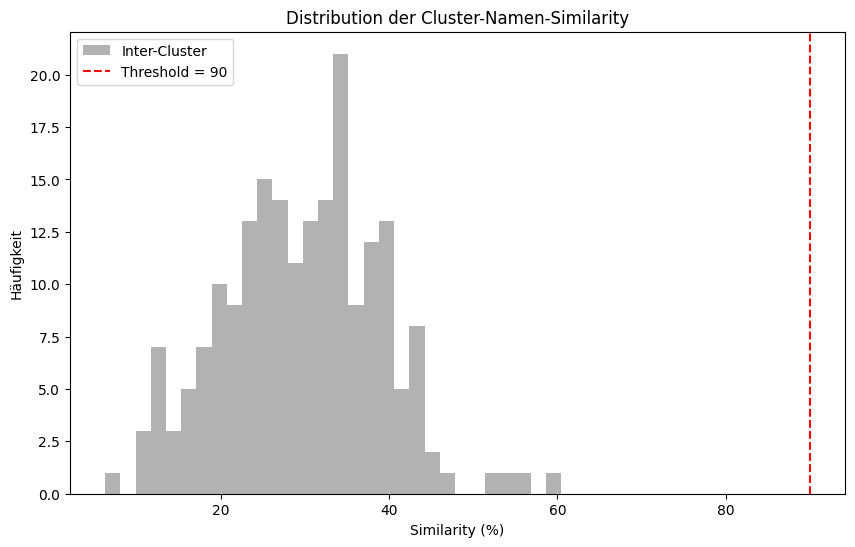

In [10]:
import pandas as pd
import numpy as np
import random
from rapidfuzz import fuzz
import matplotlib.pyplot as plt

# ================================================================
# PARAMETER
# ================================================================
input_file = "description_typOInf_correlations.csv"
threshold_similarity = 90
sample_clusters = 15
random.seed(42)

# ================================================================
# DATEN LADEN
# ================================================================
df = pd.read_csv(input_file, sep=';', dtype=str)
print("✅ Datei geladen:", input_file)
print("📊 Spalten:", df.columns.tolist())

cluster_col = next((c for c in df.columns if "cluster" in c.lower()), None)
if cluster_col is None:
    raise KeyError(f"❌ Cluster-Spalte nicht gefunden: {df.columns.tolist()}")

print(f"➡️ Verwende '{cluster_col}' als Cluster-Spalte")

# Cluster-Liste
clusters = df[cluster_col].dropna().unique().tolist()
print(f"✅ {len(clusters)} Cluster gefunden")

# ================================================================
# INTRA-CLUSTER SIMILARITY (hier nur Cluster-Namen)
# ================================================================
intra_scores = []
for cluster in random.sample(clusters, min(sample_clusters, len(clusters))):
    score = fuzz.ratio(cluster, cluster)  # nur 100%, da keine Variationen
    intra_scores.append(score)

# ================================================================
# INTER-CLUSTER SIMILARITY
# ================================================================
inter_scores = []
for _ in range(200):
    a, b = random.sample(clusters, 2)
    inter_scores.append(fuzz.ratio(a, b))

# ================================================================
# STATISTIK UND PLOT
# ================================================================
print(f"\n📊 Durchschnitt intra-cluster similarity: {np.mean(intra_scores):.2f}")
print(f"📊 Durchschnitt inter-cluster similarity: {np.mean(inter_scores):.2f}")

plt.figure(figsize=(10,6))
plt.hist(inter_scores, bins=30, alpha=0.6, label="Inter-Cluster", color="grey")
plt.axvline(threshold_similarity, color="red", linestyle="--", label=f"Threshold = {threshold_similarity}")
plt.title("Distribution der Cluster-Namen-Similarity")
plt.xlabel("Similarity (%)")
plt.ylabel("Häufigkeit")
plt.legend()
plt.show()
